<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      20 non-null     datetime64[us]
 1   manager   20 non-null     str           
 2   city      20 non-null     str           
 3   category  20 non-null     str           
 4   product   20 non-null     str           
 5   quantity  20 non-null     int64         
 6   price     20 non-null     int64         
 7   discount  20 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 1.4 KB


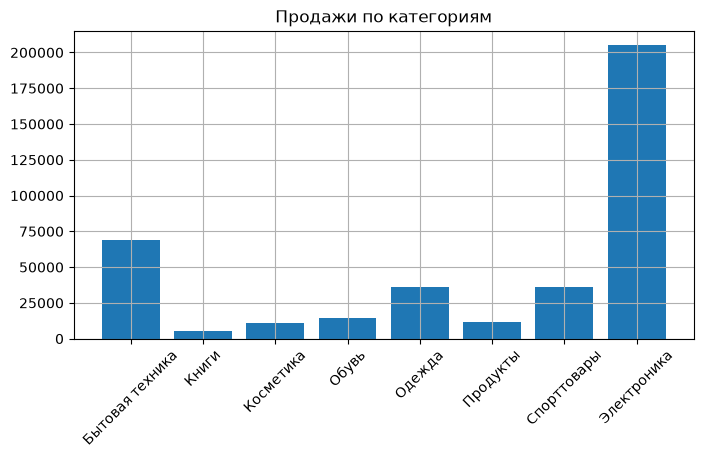

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/sales_data.xlsx")
df.head()

df.shape
df.info()
df.isna().sum()
df.describe()

df["revenue"] = df["quantity"] * df["price"] * (1 - df["discount"])
df.head()

df[df["revenue"] > 100000]

df.groupby("category")["revenue"].sum()
df.groupby("manager")["revenue"].sum()

pd.pivot_table(
    df,
    index="city",
    columns="category",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
)

sales_by_category = df.groupby("category", as_index=False)["revenue"].sum()

plt.figure(figsize=(8, 4))
plt.bar(sales_by_category["category"], sales_by_category["revenue"])
plt.xticks(rotation=45)
plt.title("Продажи по категориям")
plt.grid(True)
plt.show()
